In [1]:
import numpy as np
import pandas as pd

data = pd.read_csv(r'D:\projetPersoM2\Projet3Clustering_reductionDimension\data\Train.csv')
data.head(10)

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A
5,461319,Male,Yes,56,No,Artist,0.0,Average,2.0,Cat_6,C
6,460156,Male,No,32,Yes,Healthcare,1.0,Low,3.0,Cat_6,C
7,464347,Female,No,33,Yes,Healthcare,1.0,Low,3.0,Cat_6,D
8,465015,Female,Yes,61,Yes,Engineer,0.0,Low,3.0,Cat_7,D
9,465176,Female,Yes,55,Yes,Artist,1.0,Average,4.0,Cat_6,C


In [3]:
data.shape

(8068, 11)

In [3]:
data.isnull().sum()

ID                   0
Gender               0
Ever_Married       140
Age                  0
Graduated           78
Profession         124
Work_Experience    829
Spending_Score       0
Family_Size        335
Var_1               76
Segmentation         0
dtype: int64

In [4]:
data.isnull().mean() * 100

ID                  0.000000
Gender              0.000000
Ever_Married        1.735250
Age                 0.000000
Graduated           0.966782
Profession          1.536936
Work_Experience    10.275161
Spending_Score      0.000000
Family_Size         4.152206
Var_1               0.941993
Segmentation        0.000000
dtype: float64

In [5]:
data.duplicated().mean() * 100

np.float64(0.0)

In [10]:
df.dtypes

ID                   int64
Gender              object
Ever_Married        object
Age                  int64
Graduated           object
Profession          object
Work_Experience    float64
Spending_Score      object
Family_Size        float64
Var_1               object
Segmentation        object
dtype: object

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


In [14]:
df.describe()

,ID,Age,Work_Experience,Family_Size
count,8068.000000,8068.000000,7239.000000,7733.000000
mean,463479.214551,43.466906,2.641663,2.850123
std,2595.381232,16.711696,3.406763,1.531413
min,458982.000000,18.000000,0.000000,1.000000
25%,461240.750000,30.000000,0.000000,2.000000
50%,463472.500000,40.000000,1.000000,3.000000
75%,465744.250000,53.000000,4.000000,4.000000
max,467974.000000,89.000000,14.000000,9.000000


In [26]:
data.shape

(8068, 11)

### STATISTIQUE UNIVARIE

#### DISTRIBUTION

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_num = data.select_dtypes(include=["int64", "float64"]).columns.tolist()
cols_cat = data.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"les colonnes numerique sont {cols_num}")
print(f"les colonnes categorielles sont {cols_cat}")

les colonnes numerique sont ['ID', 'Age', 'Work_Experience', 'Family_Size']
les colonnes categorielles sont ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1', 'Segmentation']


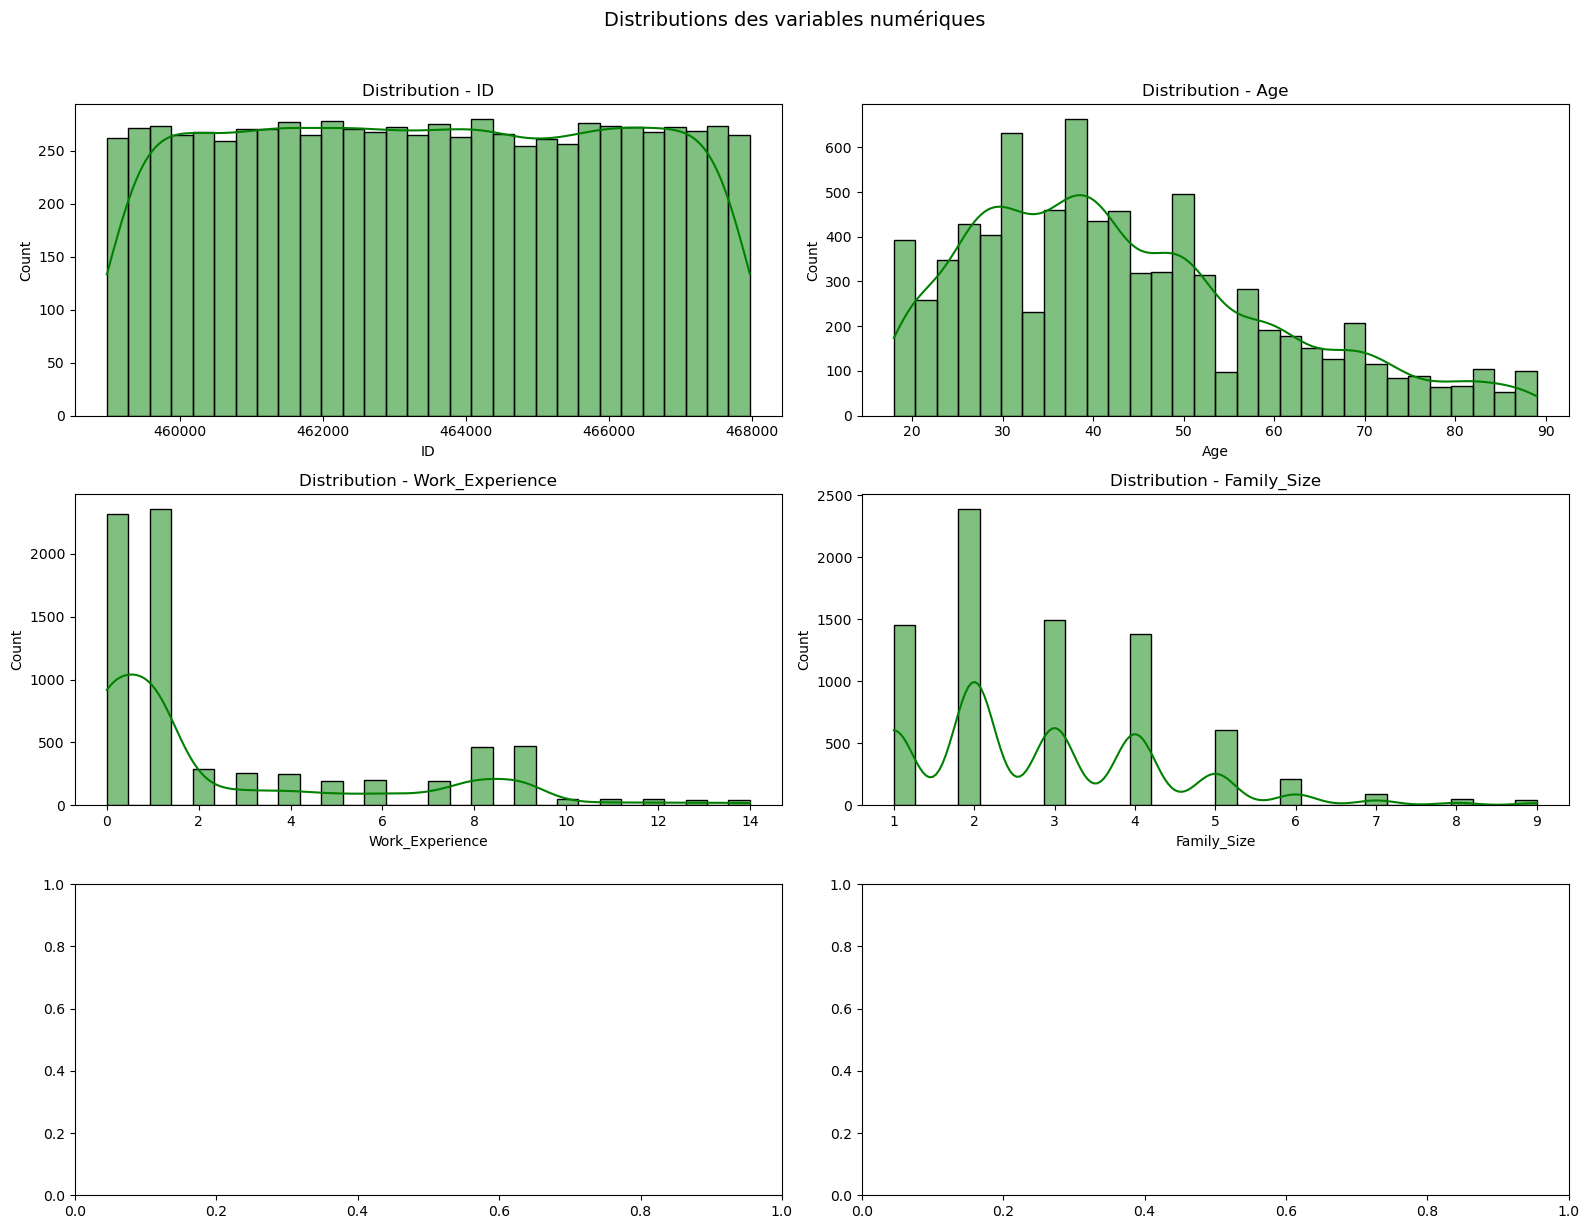

In [36]:
#on va creer des histogramme pour voir les distribution des variable numerique 
fig , axes = plt.subplots(
    nrows = (len(cols_num) + 2) // 2,
    ncols=2,
    figsize=(16, 4 * ((len(cols_num) + 2) // 2)) 
)

axes = axes.flatten()

for i, col in enumerate (cols_num):
    sns.histplot(data[col], bins=30, kde=True,
                ax= axes[i], color="green")
    axes[i].set_title(f"Distribution - {col}")
    axes[i].set_xlabel(col)

    # Cacher les axes vides
    #for j in range(i + 1, len(axes)):
     # axes[j].set_visible(False)
plt.suptitle("Distributions des variables numériques", 
         fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

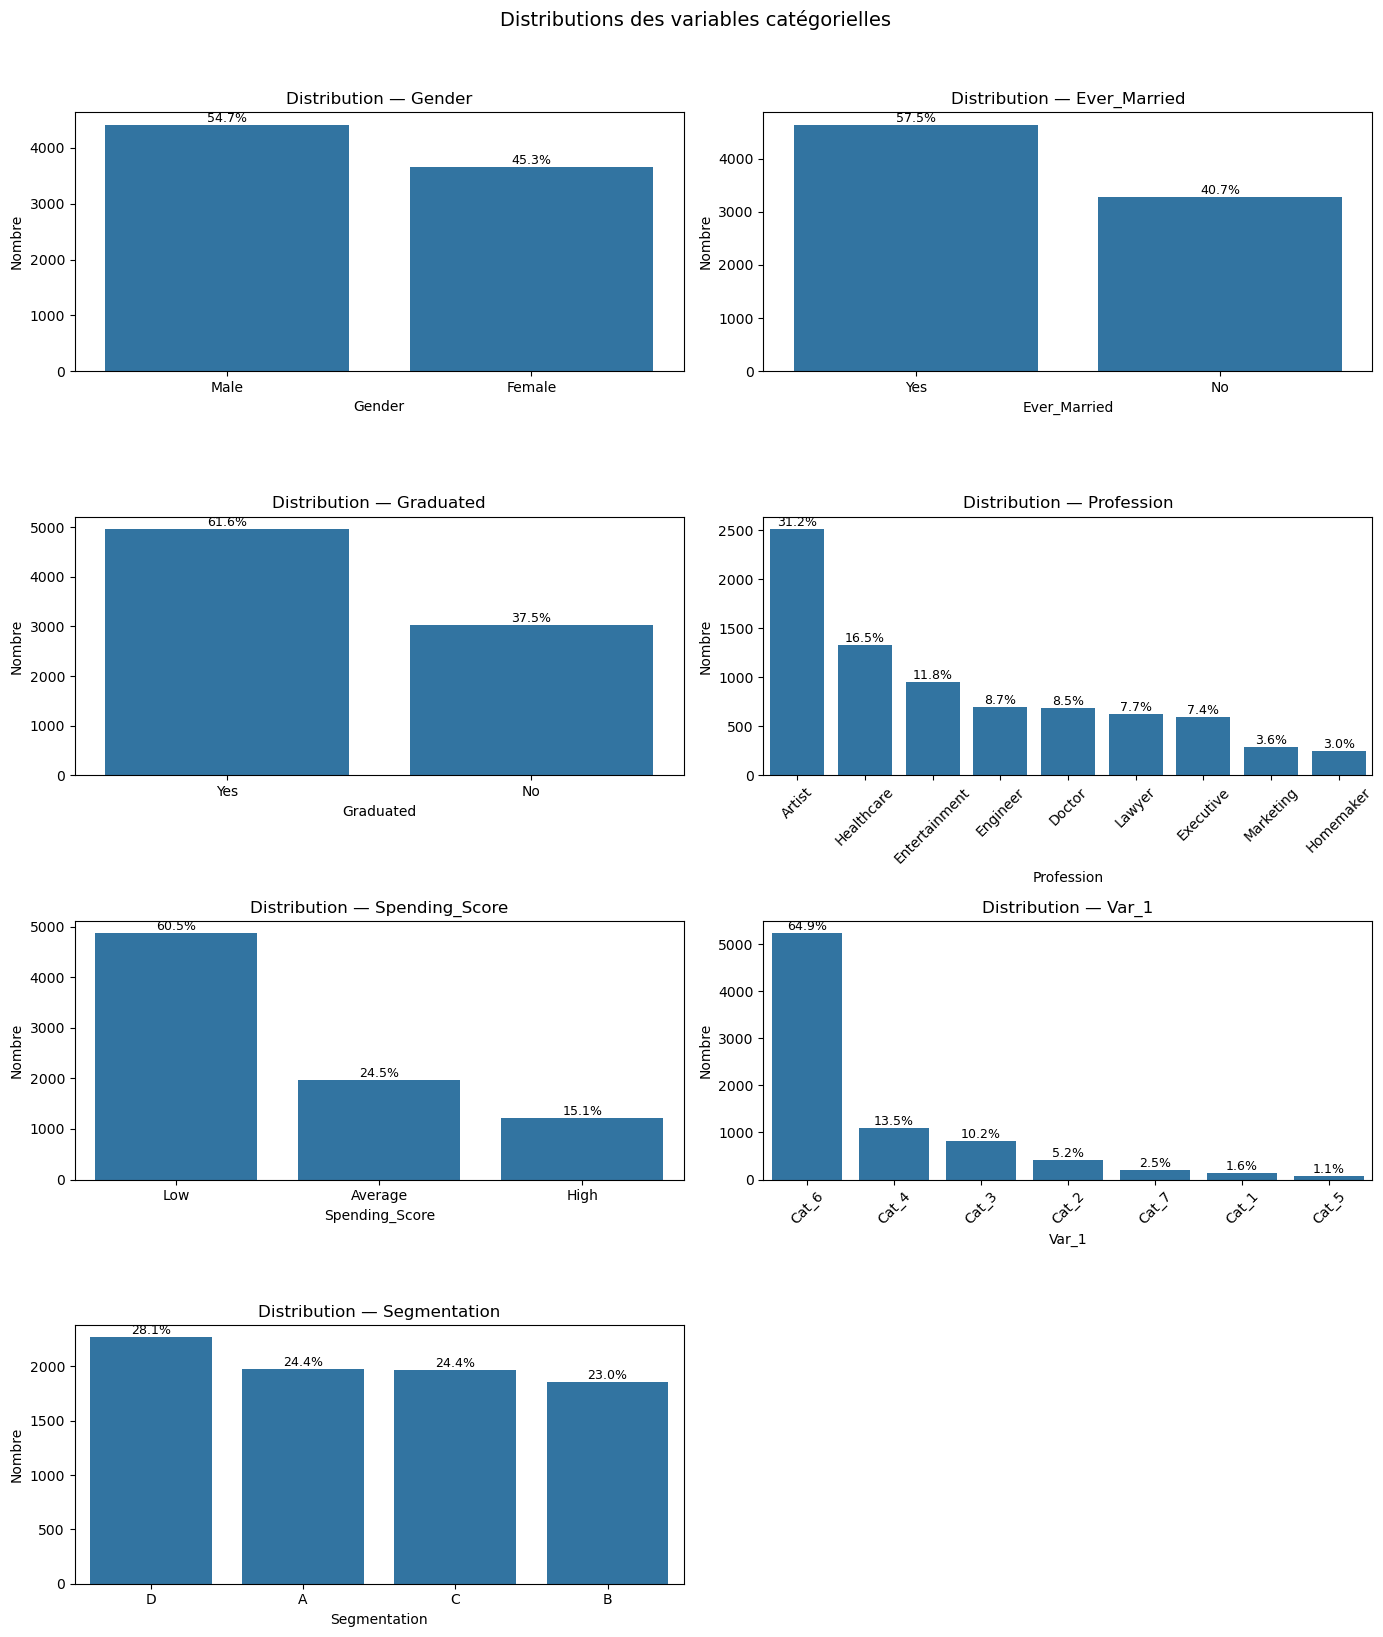

In [37]:
#distribution pour les colonnes categorielle
fig, axes = plt.subplots(
    nrows=(len(cols_cat) + 1) // 2,
    ncols=2,
    figsize=(14, 4 * ((len(cols_cat) + 1) // 2))
)
axes = axes.flatten()

for i, col in enumerate(cols_cat):
    # Trier par fréquence décroissante
    ordre = data[col].value_counts().index

    sns.countplot(data=data, x=col, ax=axes[i],
                  order=ordre)

    axes[i].set_title(f"Distribution — {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Nombre")

    # Ajouter les pourcentages sur chaque barre
    total = len(data)
    for p in axes[i].patches:
        pct = f"{100 * p.get_height() / total:.1f}%"
        axes[i].annotate(pct,
                         (p.get_x() + p.get_width() / 2,
                          p.get_height()),
                         ha="center", va="bottom",
                         fontsize=9)

    # Rotation si beaucoup de catégories
    if data[col].nunique() > 4:
        axes[i].tick_params(axis="x", rotation=45)

# Cacher les axes vides
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distributions des variables catégorielles",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### DETECTION DES OUTLIERS

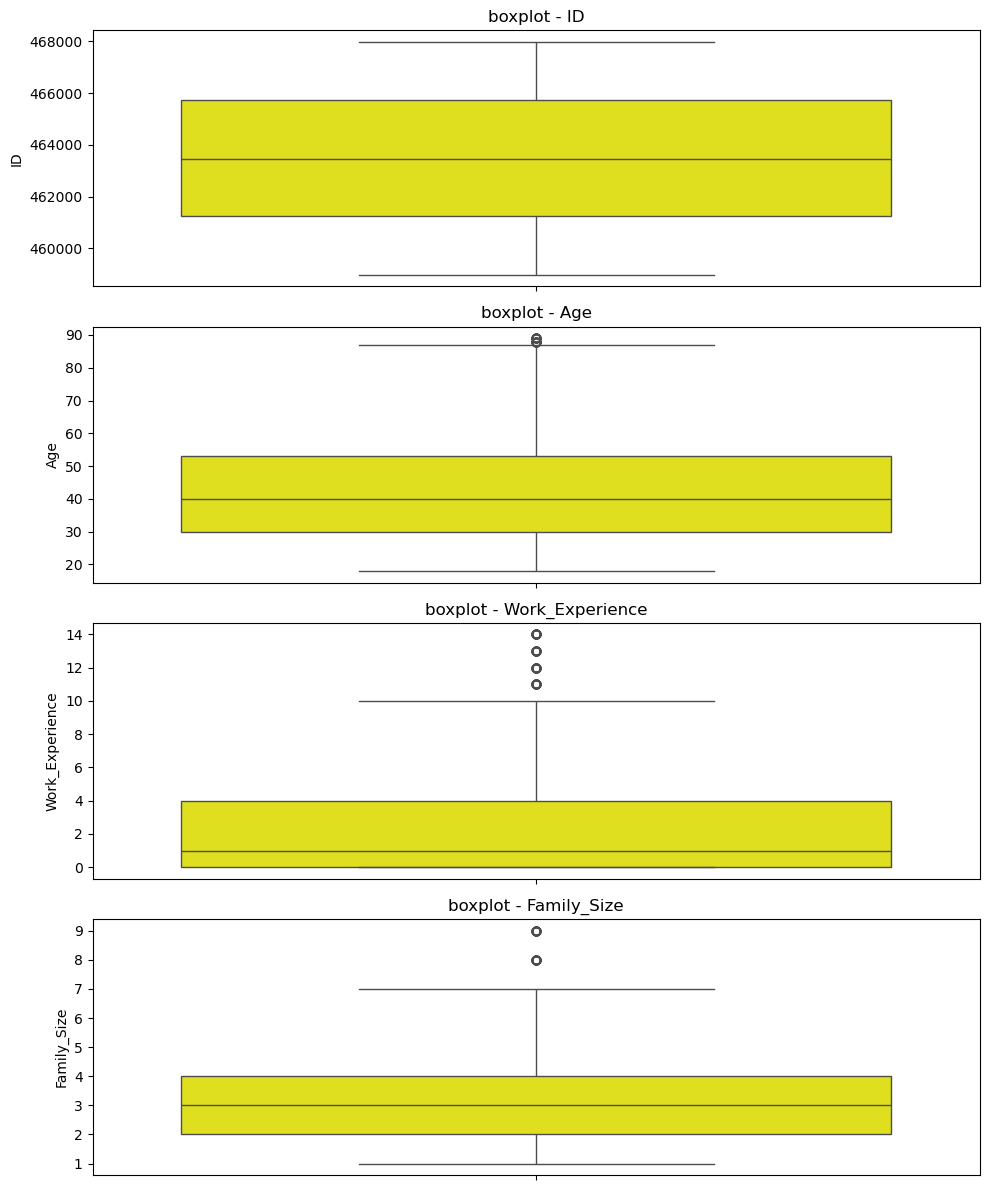

In [38]:
#on va creer des histogramme pour voir les distribution des variable numerique 
fig , axes = plt.subplots(
    len(cols_num),
    1,
    figsize=(10, 4 * ((len(cols_num) + 2) // 2)) 
)

axes = axes.flatten()

for i, col in enumerate (cols_num):
    sns.boxplot(data[col], ax= axes[i], color="yellow")
    axes[i].set_title(f"boxplot - {col}")

    # Cacher les axes vides
    #for j in range(i + 1, len(axes)):
     # axes[j].set_visible(False)
plt.tight_layout()
plt.show()

In [41]:
#methode de IQR
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 -Q1

    borne_basse = Q1 - 1.5 * IQR
    borne_haute = Q3 + 1.5 * IQR

    outliers = df[(df[col] < borne_basse) | (df[col] > borne_haute)]
    print(f"[{col}]")
    print(f"[{col}]")
    print(f"  Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}")
    print(f"  Bornes : [{borne_basse:.2f} ; {borne_haute:.2f}]")
    print(f"  Outliers détectés : {len(outliers)} "
          f"({len(outliers)/len(df)*100:.2f}%)\n")

    return outliers
for col in cols_num:
    detect_outliers_iqr(data, col)

[ID]
[ID]
  Q1=461240.75  Q3=465744.25  IQR=4503.50
  Bornes : [454485.50 ; 472499.50]
  Outliers détectés : 0 (0.00%)

[Age]
[Age]
  Q1=30.00  Q3=53.00  IQR=23.00
  Bornes : [-4.50 ; 87.50]
  Outliers détectés : 71 (0.88%)

[Work_Experience]
[Work_Experience]
  Q1=0.00  Q3=4.00  IQR=4.00
  Bornes : [-6.00 ; 10.00]
  Outliers détectés : 189 (2.34%)

[Family_Size]
[Family_Size]
  Q1=2.00  Q3=4.00  IQR=2.00
  Bornes : [-1.00 ; 7.00]
  Outliers détectés : 94 (1.17%)



In [42]:
#outlier pour les vsariables categorielle
for col in cols_cat:
    freq = data[col].value_counts(normalize=True) * 100
    print(f"\n{col}")
    print(freq.round(2))


Gender
Gender
Male      54.75
Female    45.25
Name: proportion, dtype: float64

Ever_Married
Ever_Married
Yes    58.56
No     41.44
Name: proportion, dtype: float64

Graduated
Graduated
Yes    62.18
No     37.82
Name: proportion, dtype: float64

Profession
Profession
Artist           31.67
Healthcare       16.77
Entertainment    11.95
Engineer          8.80
Doctor            8.66
Lawyer            7.84
Executive         7.54
Marketing         3.68
Homemaker         3.10
Name: proportion, dtype: float64

Spending_Score
Spending_Score
Low        60.46
Average    24.47
High       15.07
Name: proportion, dtype: float64

Var_1
Var_1
Cat_6    65.54
Cat_4    13.63
Cat_3    10.29
Cat_2     5.28
Cat_7     2.54
Cat_1     1.66
Cat_5     1.06
Name: proportion, dtype: float64

Segmentation
Segmentation
D    28.11
A    24.44
C    24.42
B    23.03
Name: proportion, dtype: float64


# ANALYSE MULTIVARIES

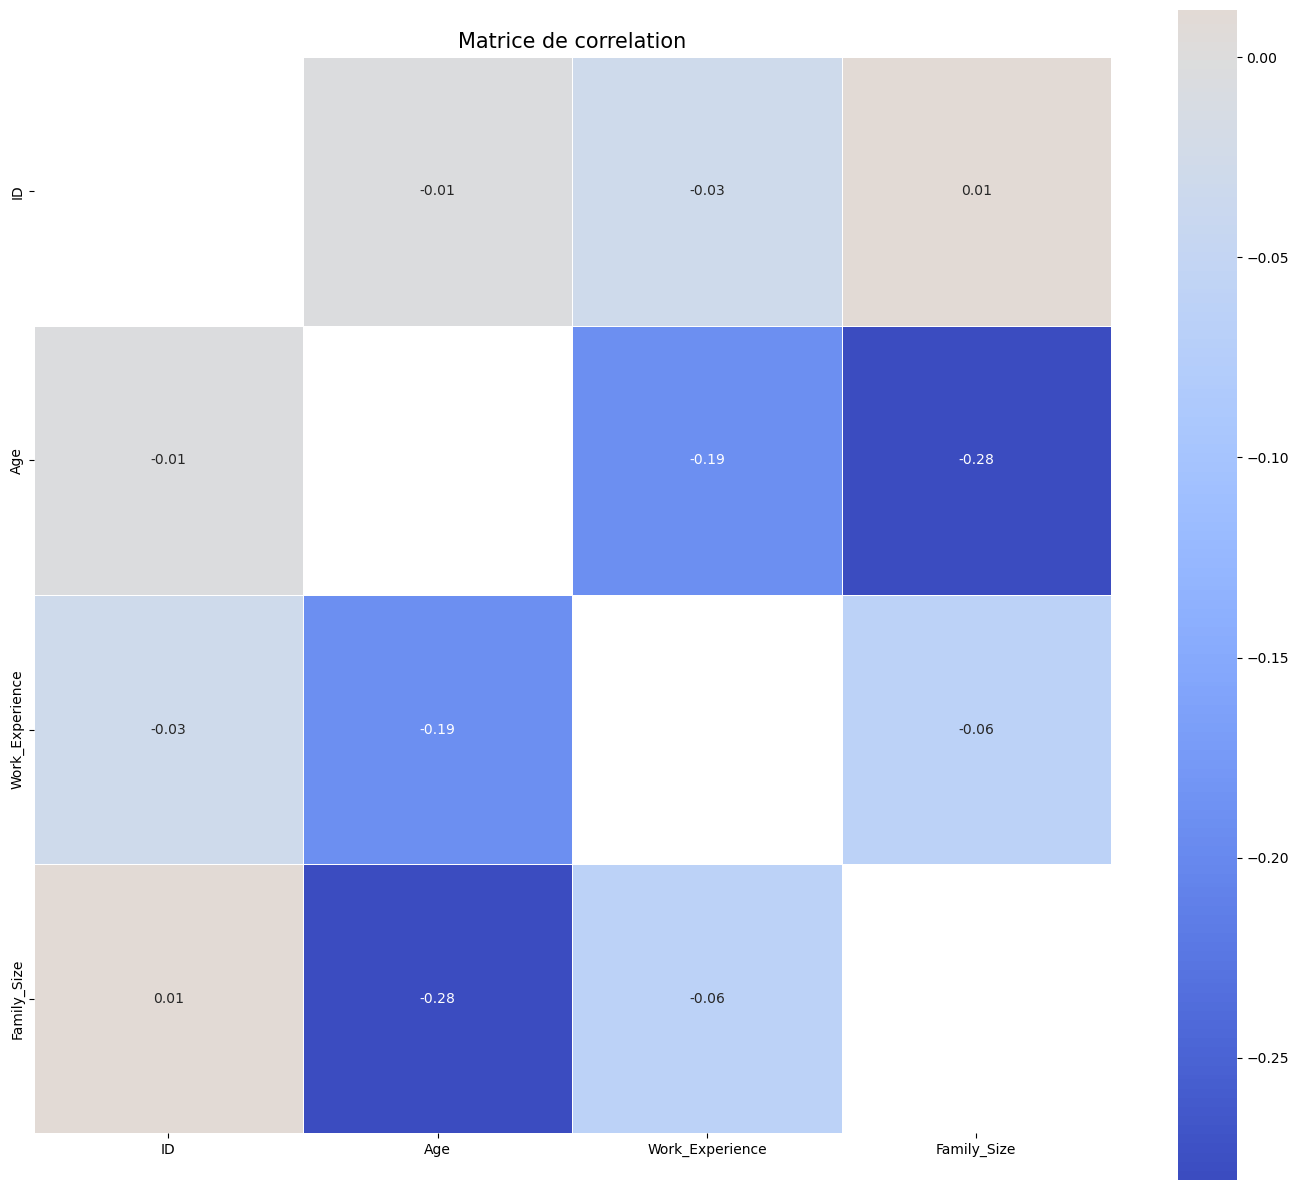

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
corr = data[cols_num].corr()

plt.figure(figsize=(14, 12))
mask = np.eye(len(corr), dtype=bool)
sns.heatmap(corr,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    mask=mask, square=True,
    linewidths=0.4
)
plt.title("Matrice de correlation", fontsize=15)
plt.tight_layout()
plt.show()

In [9]:
corr_pairs = (corr.where(
                  ~np.eye(len(corr), dtype=bool)
             )
             .stack()
             .reset_index())
corr_pairs.columns = ["Variable1","Variable2","Corrélation"]
corr_pairs["Abs"] = corr_pairs["Corrélation"].abs()
corr_pairs = corr_pairs.sort_values("Abs", ascending=False)

print("=== Corrélations les plus fortes ===")
print(corr_pairs.head(10).to_string(index=False))


=== Corrélations les plus fortes ===
      Variable1       Variable2  Corrélation      Abs
    Family_Size             Age    -0.280517 0.280517
            Age     Family_Size    -0.280517 0.280517
            Age Work_Experience    -0.190789 0.190789
Work_Experience             Age    -0.190789 0.190789
    Family_Size Work_Experience    -0.063234 0.063234
Work_Experience     Family_Size    -0.063234 0.063234
Work_Experience              ID    -0.030688 0.030688
             ID Work_Experience    -0.030688 0.030688
             ID     Family_Size     0.011801 0.011801
    Family_Size              ID     0.011801 0.011801


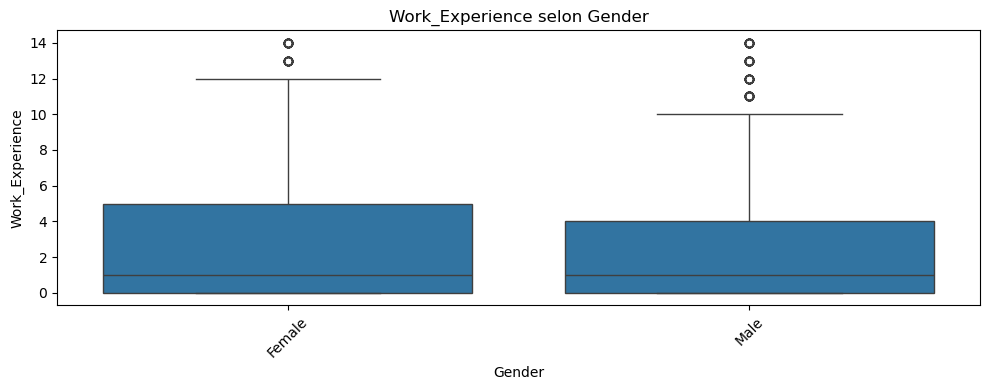

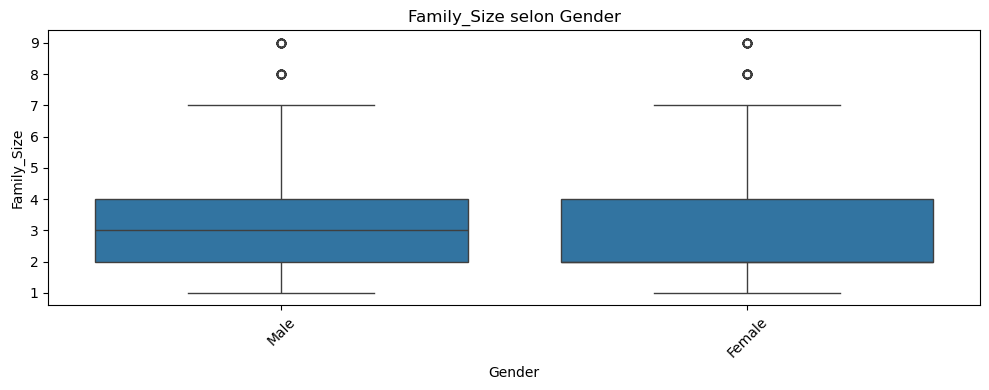

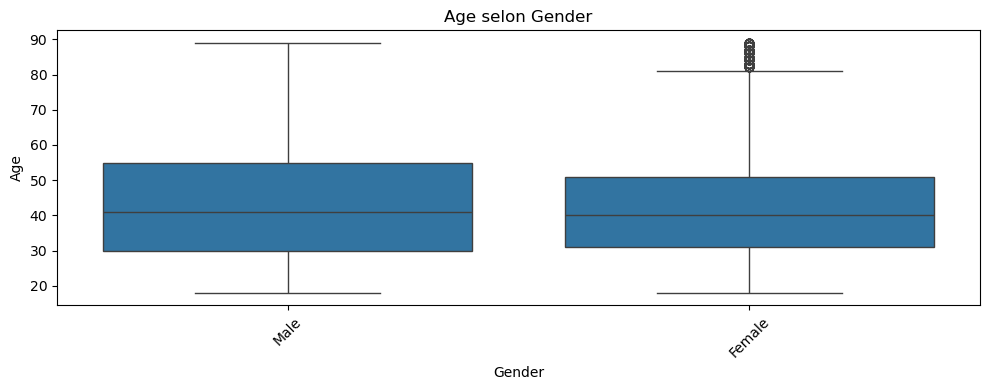

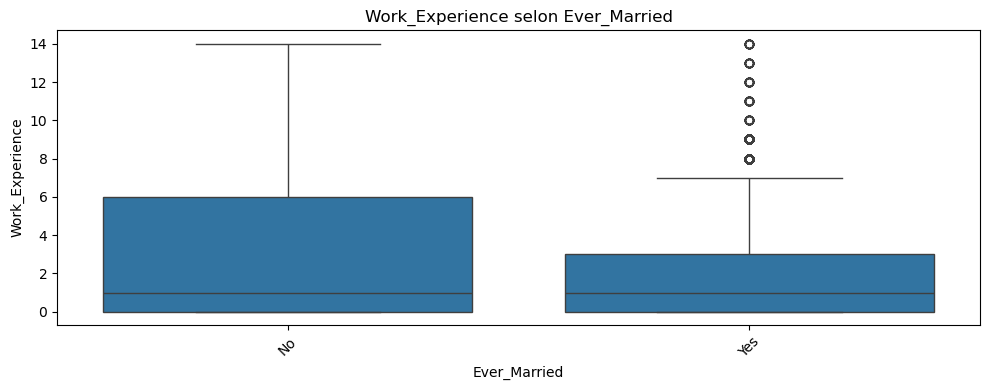

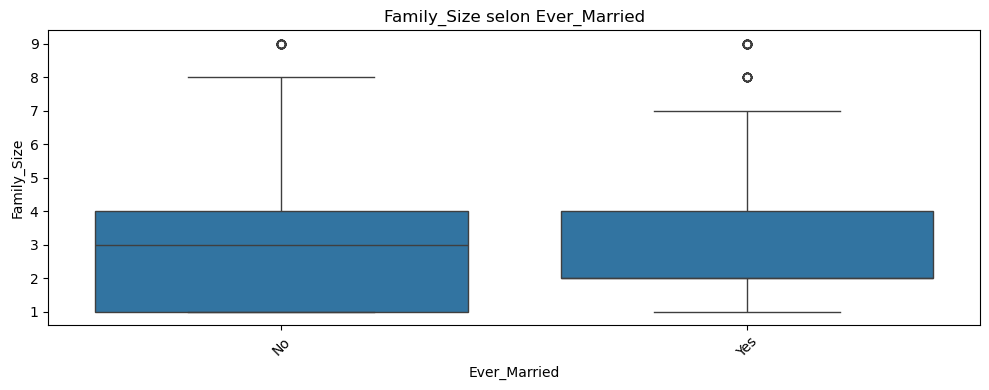

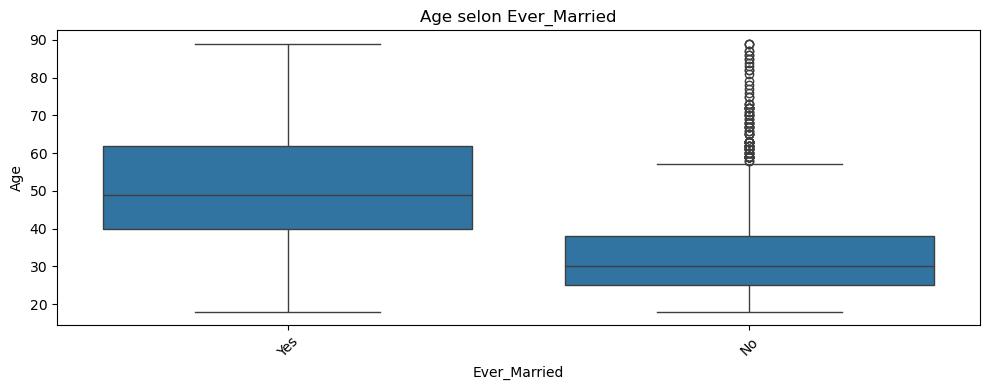

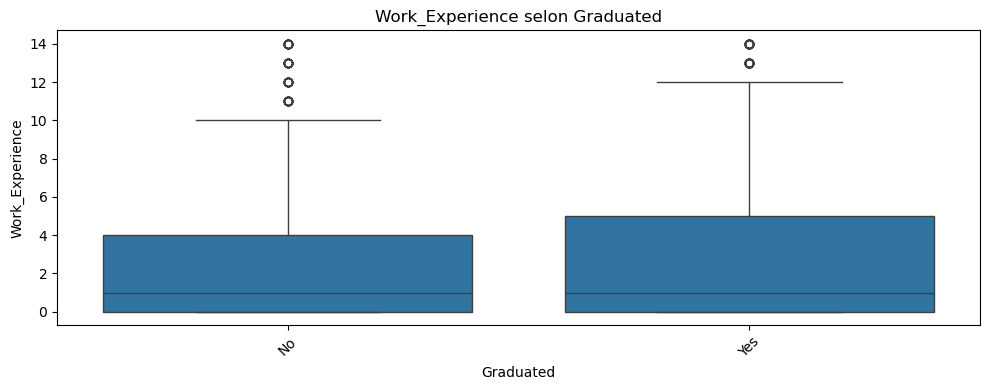

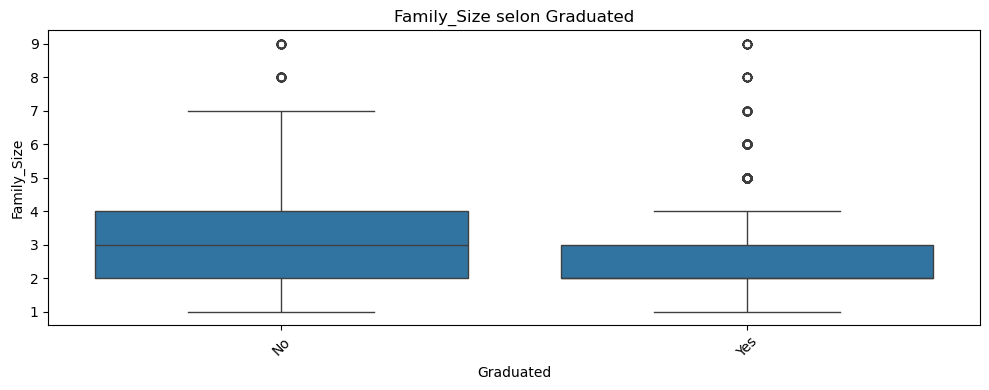

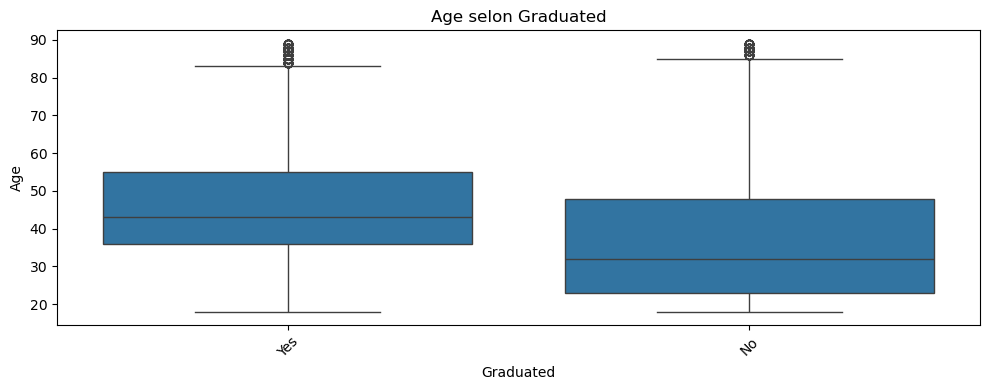

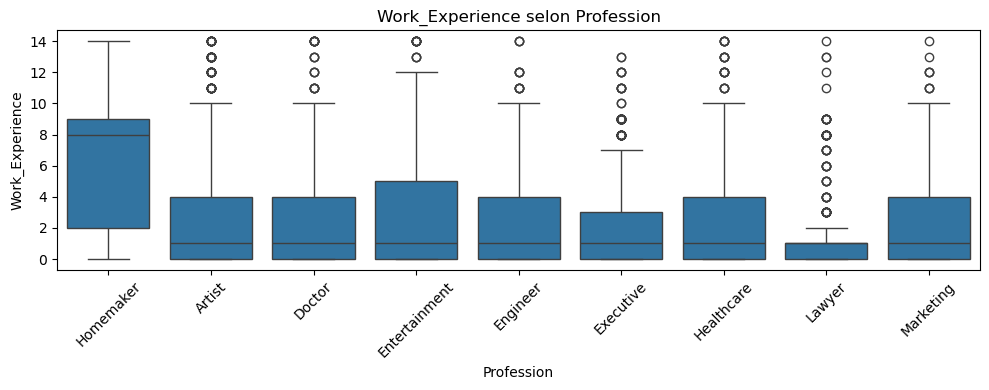

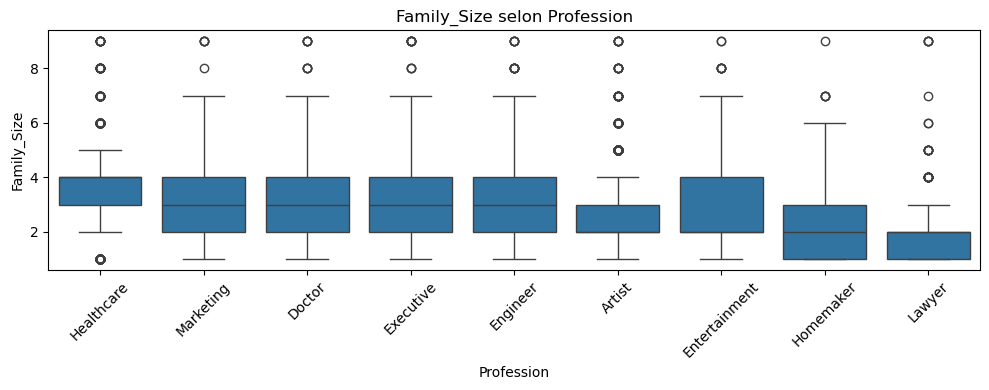

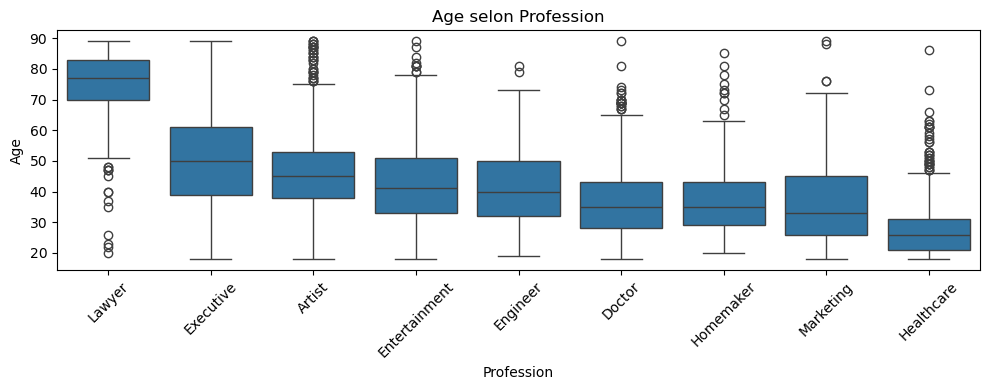

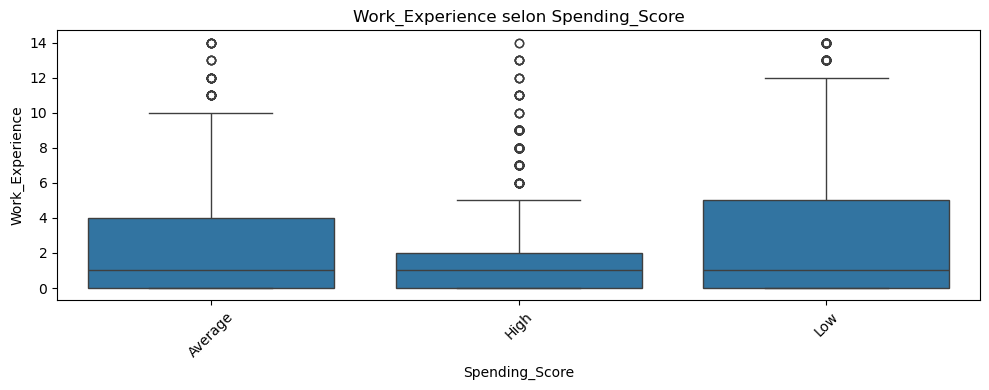

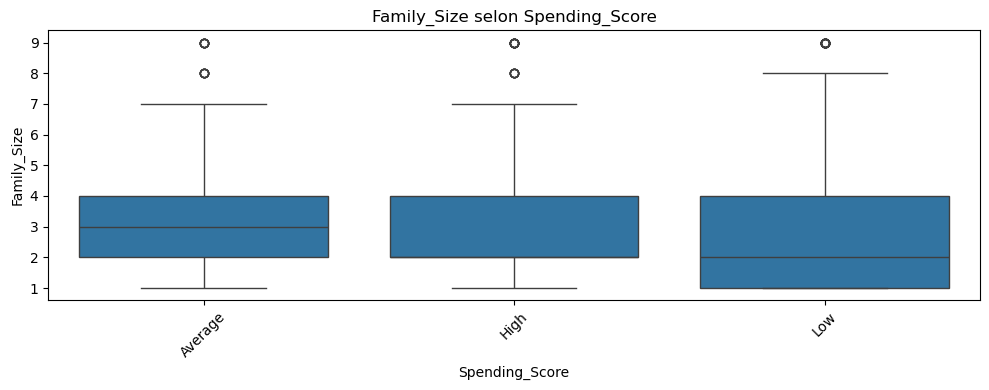

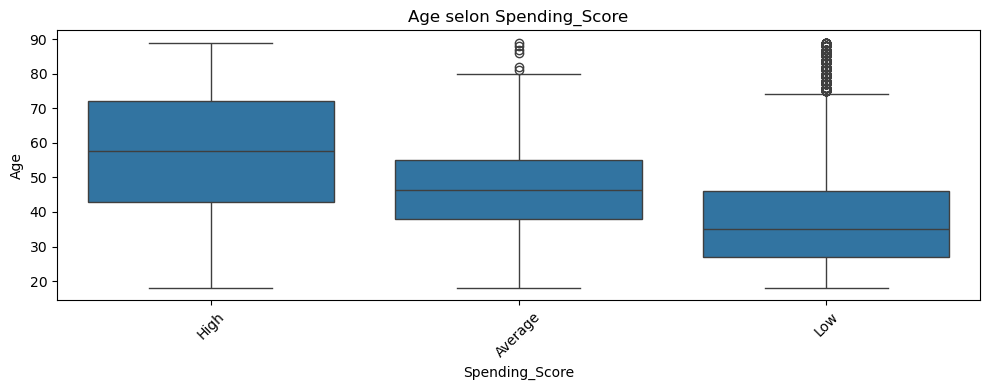

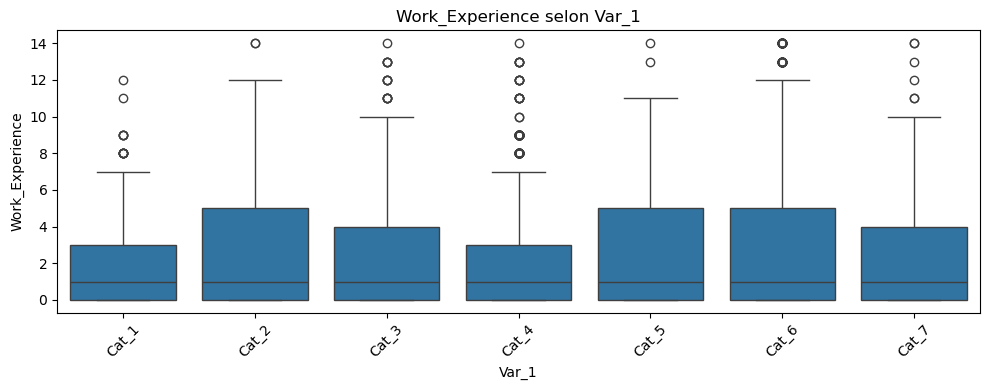

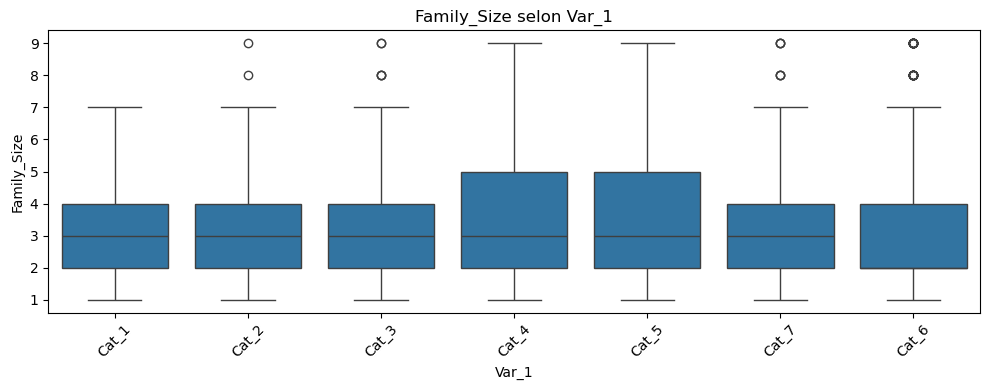

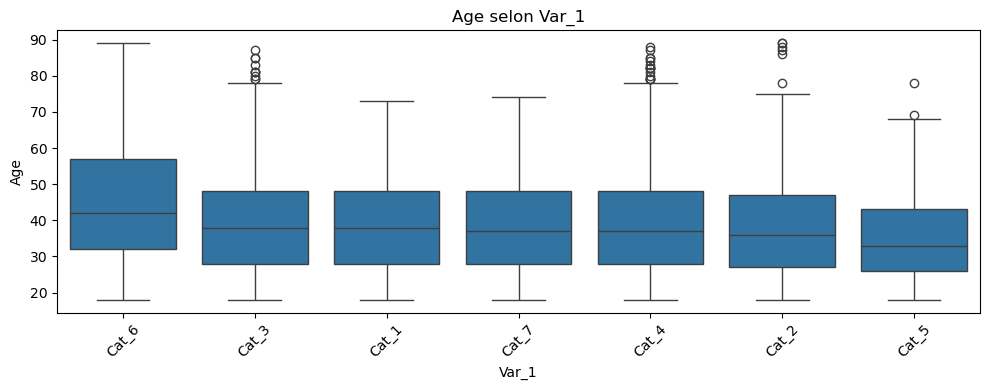

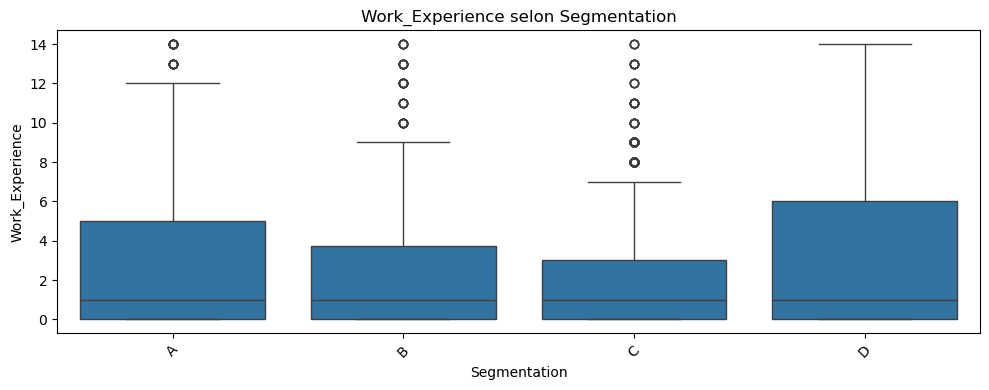

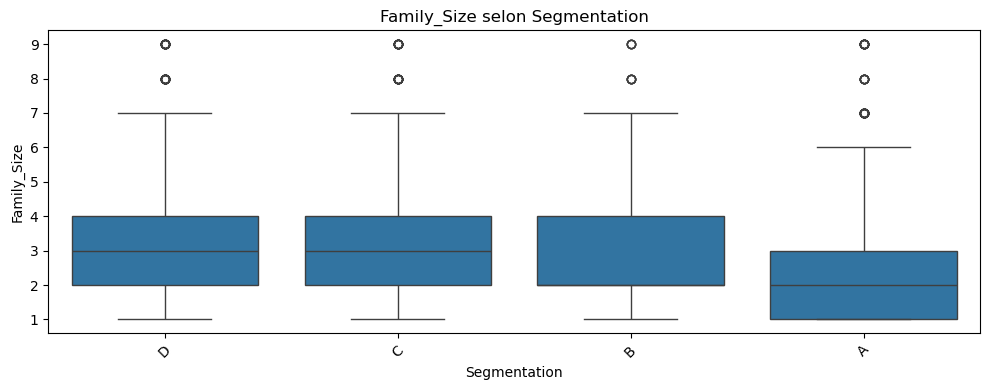

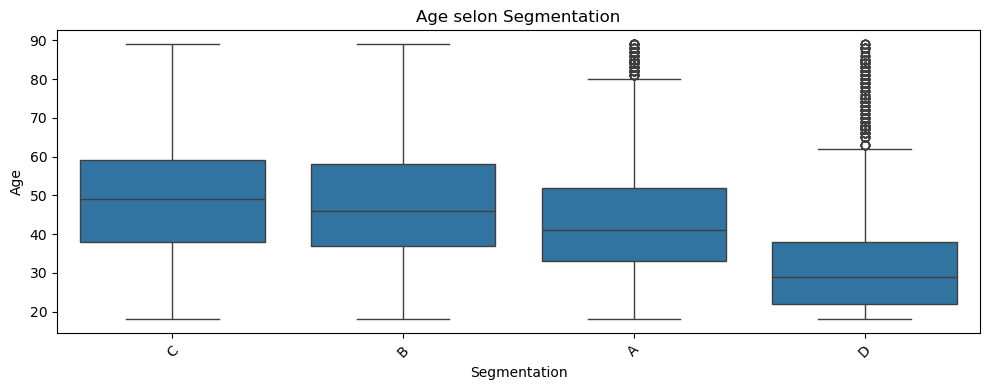

In [14]:
for cat in cols_cat:
    for num in ["Work_Experience", "Family_Size", "Age"]:
        plt.figure(figsize=(10, 4))
        ordre = (data.groupby(cat)[num]
                 .median()
                 .sort_values(ascending=False)
                 .index)
        sns.boxplot(data=data, x=cat, y=num,
                   order= ordre)
        plt.title(f"{num} selon {cat}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

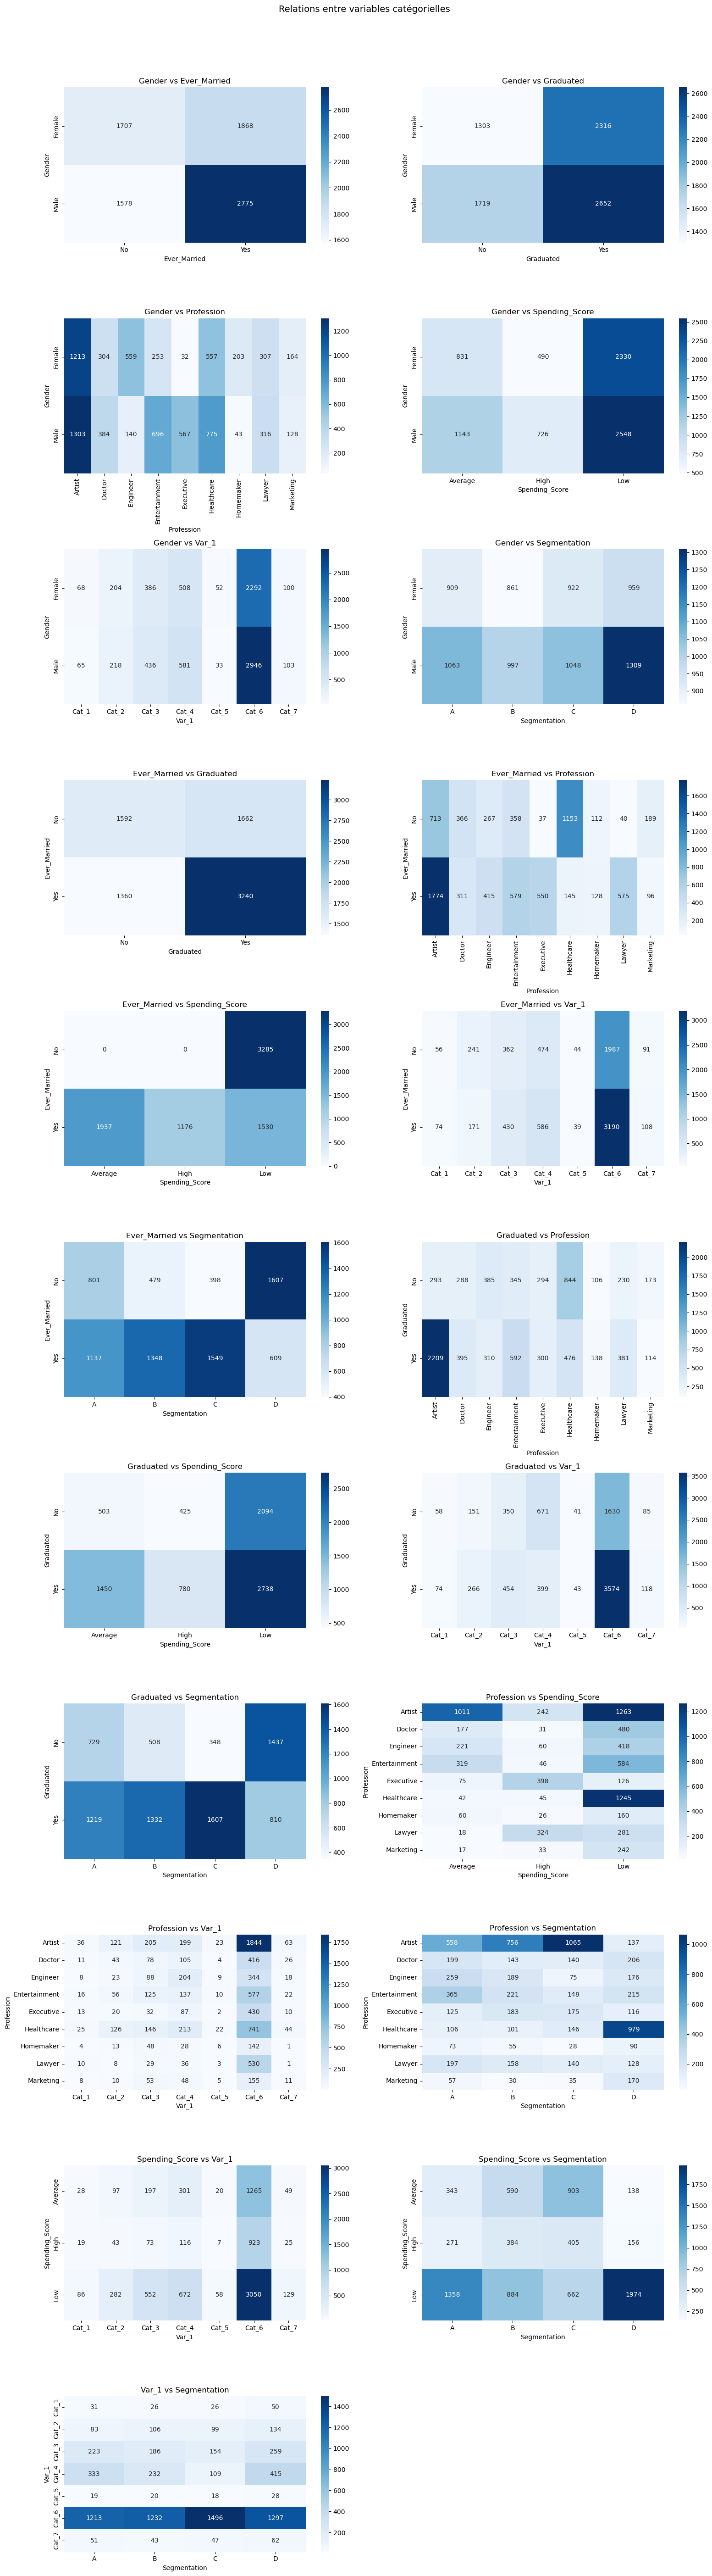

In [15]:
from itertools import combinations

#cols_cat = ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score']

pairs = list(combinations(cols_cat, 2))

fig, axes = plt.subplots(
    nrows=(len(pairs) + 1) // 2,
    ncols=2,
    figsize=(16, 5 * ((len(pairs) + 1) // 2))
)
axes = axes.flatten()

for i, (col1, col2) in enumerate(pairs):
    tableau = pd.crosstab(data[col1], data[col2])
    sns.heatmap(tableau, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f"{col1} vs {col2}")

for j in range(len(pairs), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Relations entre variables catégorielles", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### NETTOYAGE ET PRETRAITEMENT

In [3]:
#df = data.copy()
df_nettoyer = data.dropna(subset=["Ever_Married", "Graduated", "Profession", "Family_Size", "Var_1", "Work_Experience"])
df_nettoyer.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
5,461319,Male,Yes,56,No,Artist,0.0,Average,2.0,Cat_6,C
6,460156,Male,No,32,Yes,Healthcare,1.0,Low,3.0,Cat_6,C


In [3]:
df_nettoyer.shape

(6665, 11)

### ENCODAGE DES VARIABLES CATEGORIELLE
Type de variableExempleTechniqueBinaire (2 modalités)Yes/No, Male/FemaleBinary Encoding ou One-HotNominale (sans ordre)Profession, VilleOne-Hot EncodingOrdinale (avec ordre)Low/Medium/HighOrdinal EncodingOrdinale numérique1er, 2ème, 3èmeLabel Encoding

In [6]:
print(cols_cat)

['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1', 'Segmentation']


In [4]:
df_nettoyer = df_nettoyer.copy()

#pour les variables binaires
df_nettoyer['Gender_encoded'] = df_nettoyer['Gender'].map({'Male' : 1, 'Female' : 0})
df_nettoyer['Ever_Married_encoded'] = df_nettoyer['Ever_Married'].map({'Yes' : 1, 'No' : 0})
df_nettoyer['Graduated_encoded'] = df_nettoyer['Graduated'].map({'Yes' : 1, 'No' : 0})

#pour les variables ordinale
from sklearn.preprocessing import OrdinalEncoder
ordre = [['Low', 'Average', 'High']]
oe = OrdinalEncoder(categories=ordre)
df_nettoyer['Spending_Score_encoded'] = oe.fit_transform(df_nettoyer[['Spending_Score']])


#pour les variables nominale
df_nettoyer = pd.get_dummies(df_nettoyer, columns=['Profession', 'Var_1'], drop_first=False)

# ✅ CORRECTION 2 — convertir bool en int
bool_cols = df_nettoyer.select_dtypes(include='bool').columns
df_nettoyer[bool_cols] = df_nettoyer[bool_cols].astype(int)

# Étape 4 — Supprimer les colonnes originales
cols_a_supprimer = ['Gender', 'Ever_Married', 'Graduated','Spending_Score',]
df_nettoyer.drop(columns=cols_a_supprimer, inplace=True)

# Étape 5 — Mettre Segmentation de côté
segmentation = df_nettoyer['Segmentation'].copy()  # sauvegarder
df_nettoyer.drop(columns=['Segmentation'], inplace=True)  # retirer du dataset

#Étape 6 — Supprimer ID (inutile pour le clustering)
df_nettoyer.drop(columns=['ID'], inplace=True)

# Étape 7 — Vérifier
print(df_nettoyer.head())
print(df_nettoyer.shape)
print(df_nettoyer.dtypes)

   Age  Work_Experience  Family_Size  Gender_encoded  Ever_Married_encoded  \
0   22              1.0          4.0               1                     0   
2   67              1.0          1.0               0                     1   
3   67              0.0          2.0               1                     1   
5   56              0.0          2.0               1                     1   
6   32              1.0          3.0               1                     0   

   Graduated_encoded  Spending_Score_encoded  Profession_Artist  \
0                  0                     0.0                  0   
2                  1                     0.0                  0   
3                  1                     2.0                  0   
5                  0                     1.0                  1   
6                  1                     0.0                  0   

   Profession_Doctor  Profession_Engineer  ...  Profession_Homemaker  \
0                  0                    0  ...          

In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
#garder un copie original de dataset
df_avant_scaling = df_nettoyer.copy()
#standardiser
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_nettoyer)

#remettre en dataframe avec les noms de colonnes
df_scaled = pd.DataFrame(df_scaled, columns=df_nettoyer.columns)

# Étape 4 — Vérifier
print("Moyenne de chaque colonne (doit être ≈ 0) :")
print(df_scaled.mean().round(2))

print("\nÉcart-type de chaque colonne (doit être ≈ 1) :")
print(df_scaled.std().round(2))

Moyenne de chaque colonne (doit être ≈ 0) :
Age                        -0.0
Work_Experience            -0.0
Family_Size                 0.0
Gender_encoded              0.0
Ever_Married_encoded       -0.0
Graduated_encoded           0.0
Spending_Score_encoded     -0.0
Profession_Artist           0.0
Profession_Doctor          -0.0
Profession_Engineer        -0.0
Profession_Entertainment   -0.0
Profession_Executive       -0.0
Profession_Healthcare       0.0
Profession_Homemaker        0.0
Profession_Lawyer           0.0
Profession_Marketing       -0.0
Var_1_Cat_1                -0.0
Var_1_Cat_2                -0.0
Var_1_Cat_3                 0.0
Var_1_Cat_4                 0.0
Var_1_Cat_5                -0.0
Var_1_Cat_6                 0.0
Var_1_Cat_7                 0.0
dtype: float64

Écart-type de chaque colonne (doit être ≈ 1) :
Age                         1.0
Work_Experience             1.0
Family_Size                 1.0
Gender_encoded              1.0
Ever_Married_encoded        1

### PCA

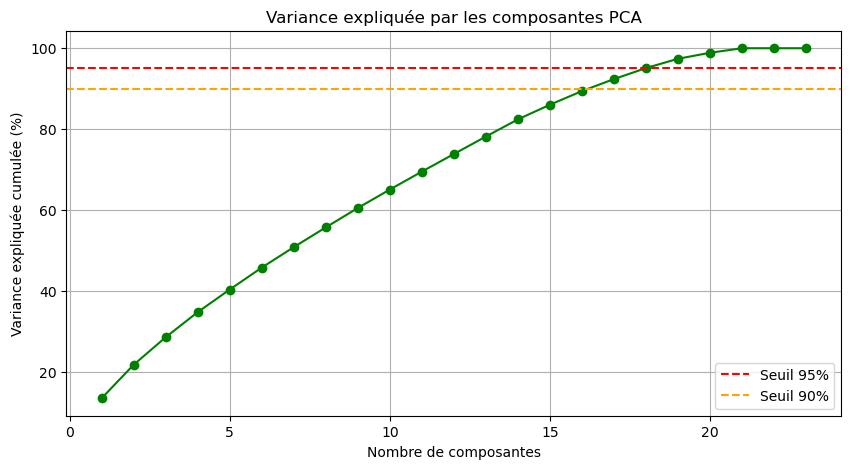

Nombre de composantes pour 95% de variance : 18


In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

#PCA pour trouver le nombre de composant
pca_full = PCA()
pca_full.fit(df_scaled)

# Variance expliquée cumulée
variance_cumulee = np.cumsum(pca_full.explained_variance_ratio_) * 100

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(variance_cumulee) + 1), 
         variance_cumulee, marker='o', color='green')
plt.axhline(y=95, color='red', linestyle='--', label='Seuil 95%')
plt.axhline(y=90, color='orange', linestyle='--', label='Seuil 90%')
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance expliquée cumulée (%)')
plt.title('Variance expliquée par les composantes PCA')
plt.legend()
plt.grid(True)
plt.show()

# Trouver le nombre de composantes pour 95%
n_composantes = np.argmax(variance_cumulee >= 95) + 1
print(f"Nombre de composantes pour 95% de variance : {n_composantes}")

In [7]:
# ✅ ÉTAPE 2 — Appliquer la PCA avec le bon nombre
pca = PCA(n_components=n_composantes)
df_pca = pca.fit_transform(df_scaled)

print(f"Forme avant PCA : {df_scaled.shape}")
print(f"Forme après PCA : {df_pca.shape}")

# Variance expliquée par chaque composante
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1} → {var*100:.1f}% de variance")

Forme avant PCA : (6665, 23)
Forme après PCA : (6665, 18)
PC1 → 13.4% de variance
PC2 → 8.3% de variance
PC3 → 6.8% de variance
PC4 → 6.2% de variance
PC5 → 5.6% de variance
PC6 → 5.4% de variance
PC7 → 5.1% de variance
PC8 → 4.9% de variance
PC9 → 4.8% de variance
PC10 → 4.6% de variance
PC11 → 4.4% de variance
PC12 → 4.4% de variance
PC13 → 4.3% de variance
PC14 → 4.3% de variance
PC15 → 3.6% de variance
PC16 → 3.4% de variance
PC17 → 3.0% de variance
PC18 → 2.7% de variance


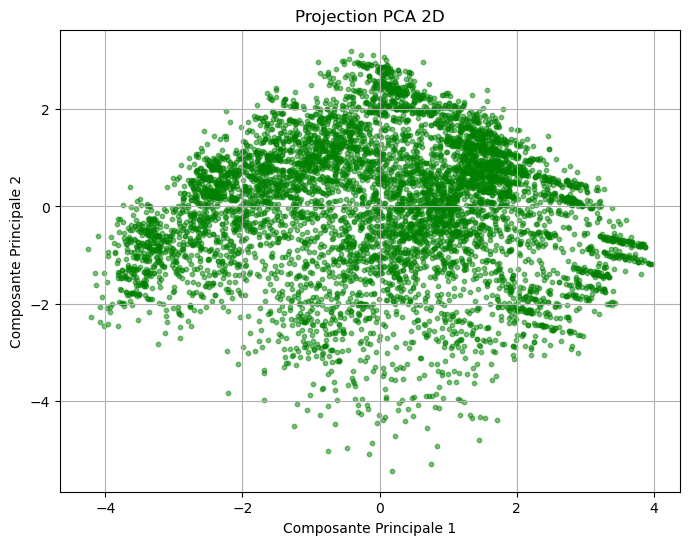

In [8]:
# ✅ ÉTAPE 3 — PCA à 2 dimensions pour visualisation
pca_2d = PCA(n_components=2)
df_pca_2d = pca_2d.fit_transform(df_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(df_pca_2d[:, 0], df_pca_2d[:, 1], 
            alpha=0.5, color='green', s=10)
plt.xlabel('Composante Principale 1')
plt.ylabel('Composante Principale 2')
plt.title('Projection PCA 2D')
plt.grid(True)
plt.show()

### CLUSTERING

#### METHODE DE COUDE

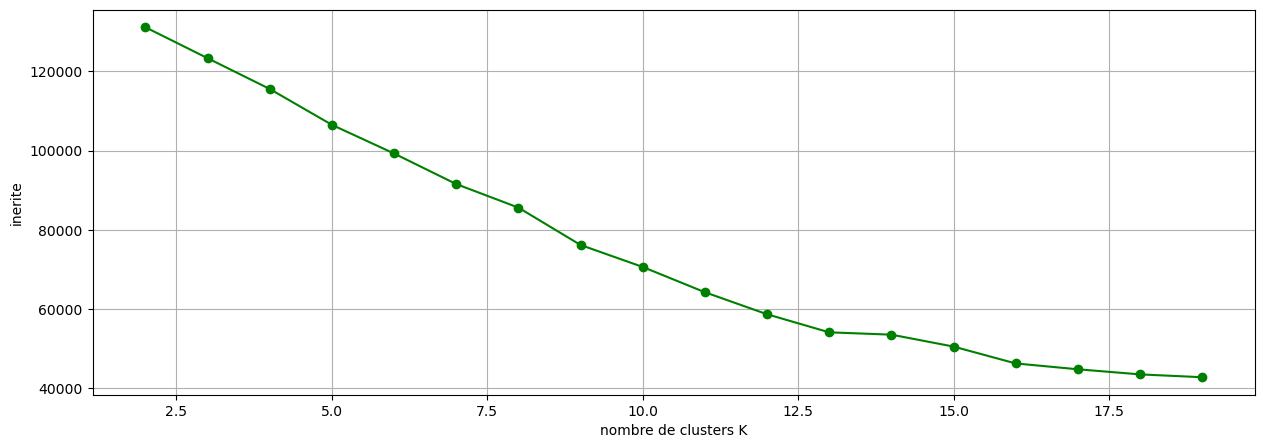

In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inerties = []
k_range = range(2, 20)

for K in k_range:
    km = KMeans(n_clusters = K, random_state=42, n_init=10)
    km.fit(df_pca)
    inerties.append(km.inertia_)

plt.figure(figsize=(15, 5))
plt.plot(k_range, inerties, marker='o', color='green')
plt.xlabel('nombre de clusters K')
plt.ylabel('inerite')
plt.grid(True)
plt.show()

#### SILHOUETTE_SCORE

K=2 -> silhouettes=0.1377
K=3 -> silhouettes=0.1439
K=4 -> silhouettes=0.1566
K=5 -> silhouettes=0.1891
K=6 -> silhouettes=0.2165
K=7 -> silhouettes=0.2304
K=8 -> silhouettes=0.2655
K=9 -> silhouettes=0.3007
K=10 -> silhouettes=0.3130
K=11 -> silhouettes=0.3216
K=12 -> silhouettes=0.3342
K=13 -> silhouettes=0.3440
K=14 -> silhouettes=0.3271
K=15 -> silhouettes=0.3278
K=16 -> silhouettes=0.2876
K=17 -> silhouettes=0.2945
K=18 -> silhouettes=0.3017
K=19 -> silhouettes=0.3045


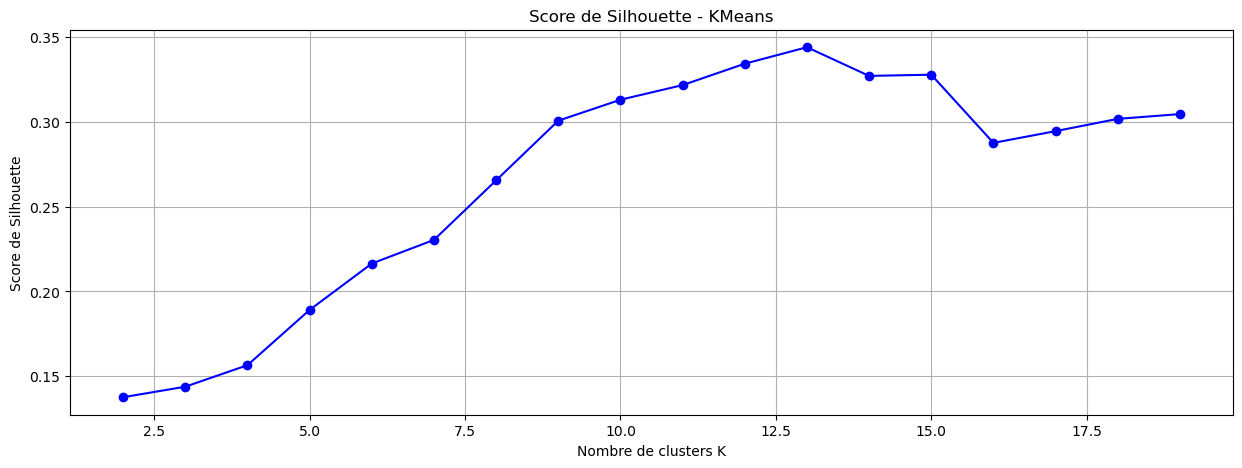

In [10]:
from sklearn.metrics import silhouette_score

silhouettes = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_pca)
    score = silhouette_score(df_pca, labels)
    silhouettes.append(score)
    print(f"K={k} -> silhouettes={score:.4f}")

plt.figure(figsize=(15, 5))
plt.plot(k_range, silhouettes, marker='o', color='blue')
plt.xlabel('Nombre de clusters K')
plt.ylabel('Score de Silhouette')
plt.title('Score de Silhouette - KMeans')
plt.grid(True)
plt.show()

In [10]:
from sklearn.cluster import KMeans

# KMeans avec K=4
km_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df_avant_scaling['Cluster_K4'] = km_4.fit_predict(df_pca)

# KMeans avec K=13
km_13 = KMeans(n_clusters=13, random_state=42, n_init=10)
df_avant_scaling['Cluster_K13'] = km_13.fit_predict(df_pca)

print("Distribution K=4 :")
print(df_avant_scaling['Cluster_K4'].value_counts())

print("\nDistribution K=13 :")
print(df_avant_scaling['Cluster_K13'].value_counts())

Distribution K=4 :
Cluster_K4
3    3379
1    1746
0    1044
2     496
Name: count, dtype: int64

Distribution K=13 :
Cluster_K13
1     1974
2      906
8      715
0      535
4      518
3      489
5      470
12     336
7      211
10     168
11     165
6      104
9       74
Name: count, dtype: int64


### CAH
Étape 1 — Départ
    → Chaque client est son propre cluster
    → N clients = N clusters

Étape 2 — Fusion progressive
    → Trouver les 2 clusters les plus proches
    → Les fusionner en 1
    → Répéter jusqu'à n'avoir plus qu'1 seul cluster

Étape 3 — Dendrogramme
    → L'arbre de fusion s'appelle un dendrogramme
    → Tu choisis où couper l'arbre pour obtenir K groupes

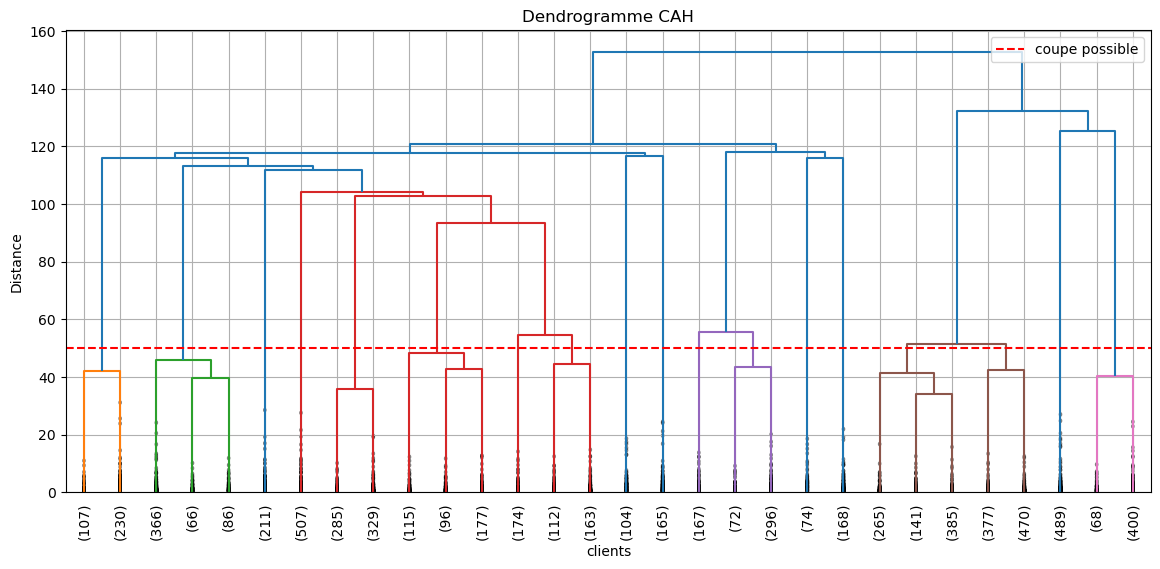

In [11]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Calculer la matrice de liaison
# ward = minimise la variance intra-cluster
Z = linkage(df_pca, method='ward')
#tracer le dendogrammme
plt.figure(figsize=(14, 6))
dendrogram(Z,
          truncate_mode='lastp', # afficher seulement les 3
          p=30,
          leaf_rotation=90,
          leaf_font_size =10,
          show_contracted=True
)
plt.title('Dendrogramme CAH')
plt.xlabel('clients')
plt.ylabel('Distance')
plt.axhline(y=50, color='red', linestyle='--', label='coupe possible')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
from scipy.cluster.hierarchy import fcluster
# Couper l'arbre pour obtenir K clusters
# on teste K=4 pour comparer avec KMeans
cah_labels_4 = fcluster(Z, t=4, criterion='maxclust')

#ajout au dataframe
df_avant_scaling['Cluster_CAH'] = cah_labels_4

print('Distribution CAH K=4')
print(df_avant_scaling['Cluster_CAH'].value_counts())

#score silouhette
from sklearn.metrics import silhouette_score
score_cah = silhouette_score(df_pca, cah_labels_4)
print(f"\nScore Silhouette CAH K=4 : {score_cah:.4f}")


Distribution CAH K=4
Cluster_CAH
1    4070
2    1638
3     489
4     468
Name: count, dtype: int64

Score Silhouette CAH K=4 : 0.1046


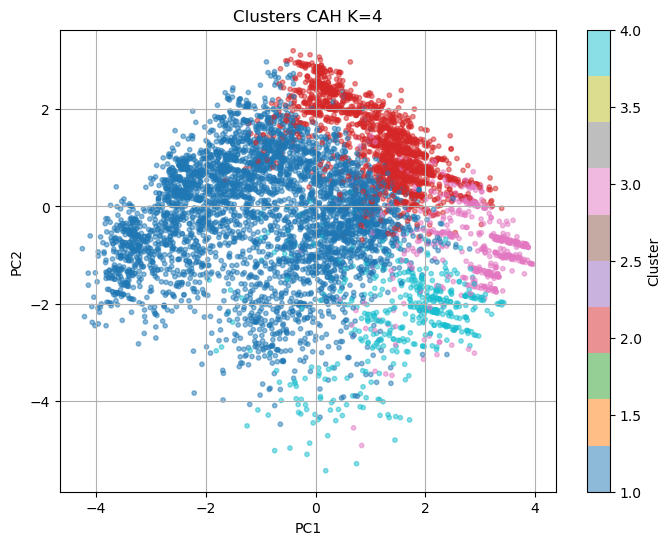

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(df_pca_2d[:, 0], df_pca_2d[:, 1],
            c=df_avant_scaling['Cluster_CAH'],
            cmap='tab10', alpha=0.5, s=10)
plt.title('Clusters CAH K=4')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

### BDSCAN
eps         → rayon de voisinage autour d'un point
              "Dans quel rayon je cherche des voisins ?"

min_samples → nombre minimum de voisins pour être un "core point"
              "Combien de voisins pour former un groupe ?"



Core Point    → a au moins min_samples voisins dans eps
                → Centre du cluster

Border Point  → moins de min_samples voisins mais proche d'un core point
                → Bord du cluster

Noise Point   → isolé, pas assez de voisins
                → Outlier (label = -1)



Étape 1 — Choisir un point non visité

Étape 2 — Compter ses voisins dans le rayon eps
    → Assez de voisins ? → Core Point → créer/étendre un cluster
    → Pas assez ?        → Border ou Noise

Étape 3 — Étendre le cluster
    → Visiter tous les voisins du core point
    → Si un voisin est aussi core point → étendre encore

Étape 4 — Répéter pour tous les points non visités

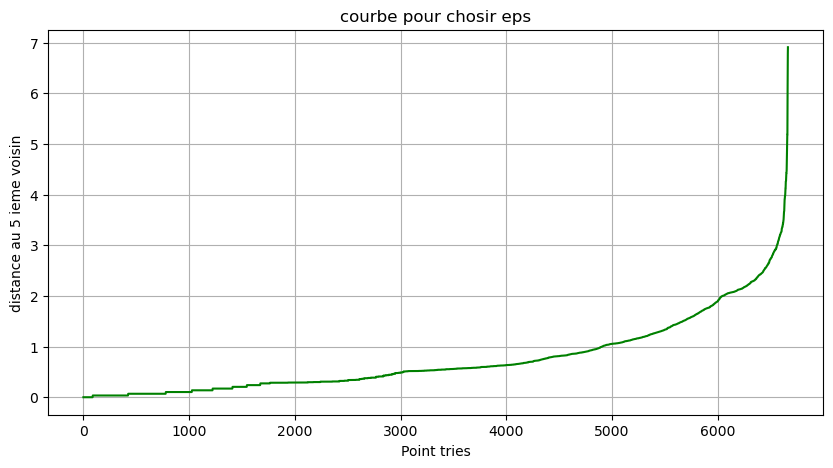

In [14]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

#calculer la distance au 5eme voisin pour chaque point
k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(df_pca)
distances, indices = nbrs.kneighbors(df_pca)
#Trier et tracer
distances_tries = np.sort(distances[:, k-1])

plt.figure(figsize=(10, 5))
plt.plot(distances_tries, color='green')
plt.xlabel('Point tries')
plt.ylabel(f'distance au {k} ieme voisin')
plt.title('courbe pour chosir eps')
plt.grid(True)
plt.show()

In [16]:
from sklearn.cluster import DBSCAN

# Appliquer DBSCAN
# eps = valeur du coude sur ta courbe (à ajuster)
# min_samples = 5 par défaut
db = DBSCAN(eps=5.0, min_samples=5)
db_labels = db.fit_predict(df_pca)

# Ajouter au dataframe
df_avant_scaling['Cluster_DBSCAN'] = db_labels

# Analyser les résultats
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_outliers = (db_labels == -1).sum()

print(f"Nombre de clusters trouvés : {n_clusters}")
print(f"Nombre d'outliers détectés : {n_outliers}")
print(f"Pourcentage outliers : {n_outliers/len(db_labels)*100:.1f}%")

print("\nDistribution DBSCAN :")
print(df_avant_scaling['Cluster_DBSCAN'].value_counts())

# Score silhouette (sans les outliers)
mask = db_labels != -1
if n_clusters > 1:
    score_db = silhouette_score(df_pca[mask], db_labels[mask])
    print(f"\nScore Silhouette DBSCAN : {score_db:.4f}")

Nombre de clusters trouvés : 9
Nombre d'outliers détectés : 8
Pourcentage outliers : 0.1%

Distribution DBSCAN :
Cluster_DBSCAN
 0    5943
 4     211
 3     167
 1     155
 2      95
 5      64
 6      10
-1       8
 8       7
 7       5
Name: count, dtype: int64

Score Silhouette DBSCAN : 0.2767


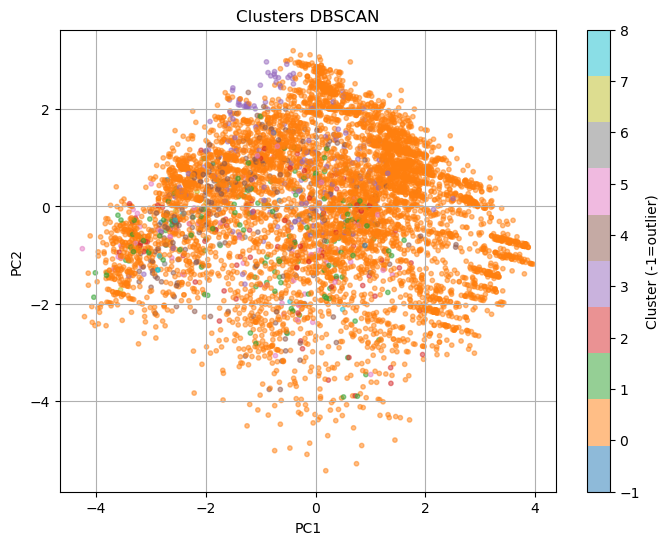

In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(df_pca_2d[:, 0], df_pca_2d[:, 1],
            c=df_avant_scaling['Cluster_DBSCAN'],
            cmap='tab10', alpha=0.5, s=10)
plt.title('Clusters DBSCAN')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='Cluster (-1=outlier)')
plt.grid(True)
plt.show()

In [18]:
print("=" * 45)
print("COMPARAISON DES ALGORITHMES")
print("=" * 45)

# KMeans K=4
score_km4 = silhouette_score(df_pca, df_avant_scaling['Cluster_K4'])
print(f"KMeans K=4     → Silhouette : {score_km4:.4f}")

# CAH K=4
print(f"CAH K=4        → Silhouette : {score_cah:.4f}")

# DBSCAN
if n_clusters > 1:
    print(f"DBSCAN         → Silhouette : {score_db:.4f}")
    print(f"DBSCAN         → Outliers   : {n_outliers}")

print("=" * 45)

COMPARAISON DES ALGORITHMES
KMeans K=4     → Silhouette : 0.1566
CAH K=4        → Silhouette : 0.1046
DBSCAN         → Silhouette : 0.2767
DBSCAN         → Outliers   : 8


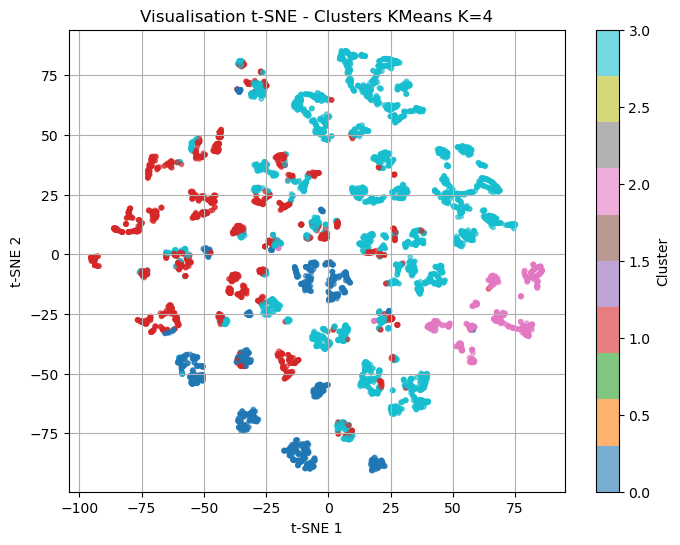

In [20]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Appliquer t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
df_tsne = tsne.fit_transform(df_pca)

# Visualiser avec les clusters KMeans
plt.figure(figsize=(8, 6))
plt.scatter(df_tsne[:, 0], df_tsne[:, 1],
            c=df_avant_scaling['Cluster_K4'],
            cmap='tab10', alpha=0.6, s=10)
plt.title('Visualisation t-SNE - Clusters KMeans K=4')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()